In [13]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt


In [28]:

adata = sc.read_h5ad('/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/myeloid.h5ad')

/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [29]:
for celltype in adata.obs['Prelim annotation'].unique():
    print(celltype)

Macrophages Cycling
Macrophages Tissue Resident
DC cDC2
DC cDC1
DC migDC
Monocytes
doublet
Fibroblasts Follicular Dendritic Cells (fDC)
Macrophages M2
Granulocytes Mast Cells
DC Monocyte derived dendritic cell
(MO DC)
Granulocytes


In [4]:
for celltype in adata.obs['dataset_id'].unique():
    print(celltype)

BasuGCARNA
Zheng2024
He2020
Huang2019
James2020_5p
Yu2021
ArendsHelmsley
Burclaff2022
KarakashevaHelmlsey
Krzak2023
Maddipatla2023
Kong2023_v3
Kong2023_v2
Elmentaite2020
Lee2020
Martin2019
Parikh2019
Uzzan2022
Wang2020
Luoma2020


## Something cool about the pre-pub data

In [17]:
paths = {
    "lymphoid": "/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/lymphoid.h5ad",
    "stroma": "/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/stroma.h5ad",
    "myeloid": "/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/myeloid.h5ad",
    "epithelial": "/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/epithelial.h5ad",
}

prepub_ids = {
    "ArendsHelmsley",
    "DominguezUnpub2",
    "DominguezUnpub",
    "BasuGCARNA",
    "KarakashevaHelmlsey",
}

tissue_col = "tissue_ontology_term"
ct_col = "Prelim annotation"
dataset_col = "dataset_id"
sym_col = "gene_symbol"

/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


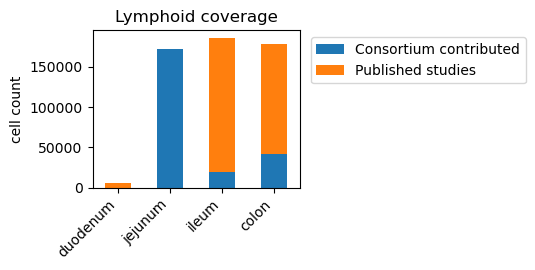

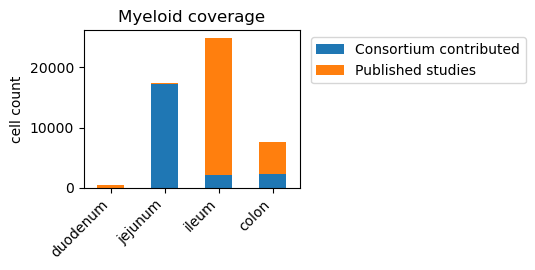

In [21]:
def segment_from_tissue(x):
    s = str(x).lower()
    if "duod" in s:
        return "duodenum"
    if "jejun" in s:
        return "jejunum"
    if "ile" in s:
        return "ileum"
    if "colon" in s or "large intestine" in s:
        return "colon"
    return "other"

def add_common_obs(ad):
    ad = ad.copy()
    ad.obs["segment_simple"] = ad.obs[tissue_col].map(segment_from_tissue)
    ad.obs["data_provenance"] = np.where(
        ad.obs[dataset_col].astype(str).isin(list(prepub_ids)),
        "Consortium contributed",
        "Published studies",
    )
    keep = ["duodenum", "jejunum", "ileum", "colon"]
    ad = ad[ad.obs["segment_simple"].isin(keep)].copy()
    return ad

def resolve_symbols_to_varnames(ad, symbols):
    if sym_col in ad.var.columns:
        s = ad.var[sym_col].astype(str).values
        out = []
        for g in symbols:
            idx = np.where(s == g)[0]
            if idx.size > 0:
                out.append(ad.var_names[int(idx[0])])
        return out
    return [g for g in symbols if g in ad.var_names]

adata_by_lineage = {k: add_common_obs(sc.read_h5ad(v)) for k, v in paths.items()}

# Plot A: show that consortium contributed data fills the jejunum immune gap
def plot_gap(ad, title):
    seg_order = ["duodenum", "jejunum", "ileum", "colon"]
    prov_order = ["Consortium contributed", "Published studies"]
    tab = pd.crosstab(ad.obs["segment_simple"], ad.obs["data_provenance"]).reindex(seg_order).fillna(0)
    tab = tab[prov_order]
    ax = tab.plot(kind="bar", stacked=True, figsize=(5.5, 2.8))
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("cell count")
    ax.set_xticklabels(seg_order, rotation=45, ha="right")
    ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_gap(adata_by_lineage["lymphoid"], "Lymphoid coverage")
plot_gap(adata_by_lineage["myeloid"], "Myeloid coverage")


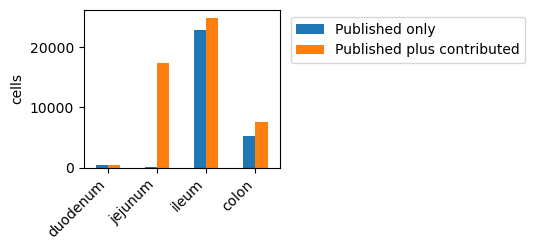

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

tab_pub = ad_pub.obs[seg_col].value_counts().reindex(seg_order).fillna(0)
tab_all = ad_all.obs[seg_col].value_counts().reindex(seg_order).fillna(0)

df = pd.DataFrame({"Published only": tab_pub, "Published plus contributed": tab_all})

ax = df.plot(kind="bar", figsize=(5.5, 2.6))
ax.set_xlabel("")
ax.set_ylabel("cells")
ax.set_xticklabels(seg_order, rotation=45, ha="right")
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


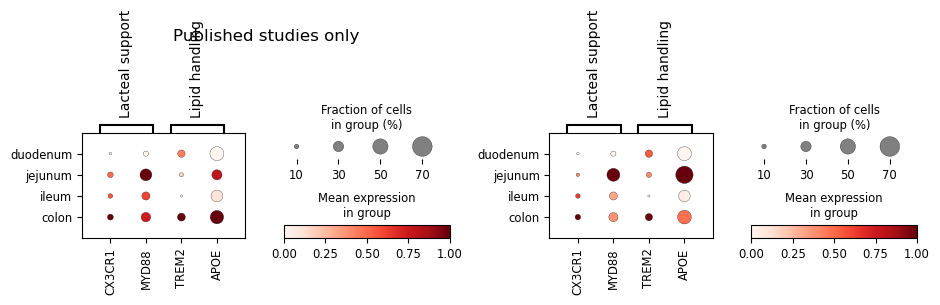

In [39]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcdefaults()

prepub_ids = {
    "ArendsHelmsley",
    "DominguezUnpub2",
    "DominguezUnpub",
    "BasuGCARNA",
    "KarakashevaHelmlsey",
}

tissue_col = "tissue_ontology_term"
dataset_col = "dataset_id"
seg_col = "segment_simple"
sym_col = "gene_symbol"

def segment_from_tissue(x):
    s = str(x).lower()
    if "duod" in s:
        return "duodenum"
    if "jejun" in s:
        return "jejunum"
    if "ile" in s:
        return "ileum"
    if "colon" in s or "large intestine" in s:
        return "colon"
    return "other"

ad = adata_by_lineage["myeloid"]  # use your myeloid object here
ad.obs[seg_col] = ad.obs[tissue_col].map(segment_from_tissue)

ad.obs["is_prepub"] = ad.obs[dataset_col].astype(str).isin(list(prepub_ids))
ad.obs["provenance"] = np.where(ad.obs["is_prepub"], "Consortium contributed", "Published studies")

seg_order = ["duodenum", "jejunum", "ileum", "colon"]
ad = ad[ad.obs[seg_col].isin(seg_order)].copy()
ad.obs[seg_col] = pd.Categorical(ad.obs[seg_col].astype(str), categories=seg_order, ordered=True)

ad_pub = ad[ad.obs["provenance"] == "Published studies"].copy()
ad_all = ad.copy()

markers = {
    "Lacteal support": ["VEGFC", "CSF1R", "CX3CR1", "MRC1"],
    "Lipid handling": ["APOE", "LPL", "CD36", "FABP5", "TREM2"],
}

mac_mask = ad.obs[ct_col].astype(str).str.contains("mac|mdm|mono", case=False, regex=True)
mac = ad[mac_mask].copy()

seg_order = ["duodenum","jejunum","ileum","colon"]
mac.obs["segment_simple"] = pd.Categorical(mac.obs["segment_simple"].astype(str), categories=seg_order, ordered=True)

mac_pub = mac[mac.obs["provenance"] == "Published studies"].copy()
mac_all = mac.copy()

markers = {
    "Lacteal support": ["CX3CR1", "MYD88"],
    "Lipid handling": ["TREM2", "APOE"],
}

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.0), sharey=True)

sc.pl.dotplot(
    mac_pub,
    var_names=markers,
    groupby="segment_simple",
    gene_symbols=sym_col if sym_col in mac_pub.var.columns else None,
    standard_scale="var",
    dot_max=0.7,
    ax=axes[0],
    show=False,
)
axes[0].set_title("Published studies only")

sc.pl.dotplot(
    mac_all,
    var_names=markers,
    groupby="segment_simple",
    gene_symbols=sym_col if sym_col in mac_all.var.columns else None,
    standard_scale="var",
    dot_max=0.7,
    ax=axes[1],
    show=False,
)
# axes[1].set_title("Published plus contributed")

plt.tight_layout()
plt.show()

In [36]:
adata.obs['provenance'].value_counts()

provenance
Published      28618
Contributed    21639
Name: count, dtype: int64

In [46]:
from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests

adata = adata_by_lineage["myeloid"]  

adata.obs["segment_simple"] = adata.obs[tissue_col].map(segment_from_tissue)
adata = adata[adata.obs["segment_simple"].isin(["duodenum", "jejunum", "ileum", "colon"])].copy()

adata.obs["provenance"] = np.where(
    adata.obs[dataset_col].astype(str).isin(list(prepub_ids)),
    "Contributed",
    "Published",
)

def varname_for_symbol(ad, symbol):
    if sym_col in ad.var.columns:
        s = ad.var[sym_col].astype(str).values
        idx = np.where(s == symbol)[0]
        if idx.size > 0:
            return ad.var_names[int(idx[0])]
        return None
    if symbol in ad.var_names:
        return symbol
    return None

def get_expr(ad, gene_varname):
    x = ad[:, [gene_varname]].X
    if hasattr(x, "toarray"):
        x = x.toarray()
    return np.asarray(x).reshape(-1)

def compute_gene_celltype_tests(ad, gene_symbols, seg_a="jejunum", seg_b="ileum", min_cells=50):
    out = []
    for ct in ad.obs[ct_col].astype(str).unique():
        sub = ad[ad.obs[ct_col].astype(str) == ct].copy()
        a_mask = sub.obs["segment_simple"].astype(str) == seg_a
        b_mask = sub.obs["segment_simple"].astype(str) == seg_b
        na = int(a_mask.sum())
        nb = int(b_mask.sum())
        if na < min_cells or nb < min_cells:
            continue

        for gsym in gene_symbols:
            gvar = varname_for_symbol(sub, gsym)
            if gvar is None:
                continue
            xa = get_expr(sub[a_mask], gvar)
            xb = get_expr(sub[b_mask], gvar)

            stat, p = ranksums(xa, xb)

            med_a = float(np.median(xa))
            med_b = float(np.median(xb))
            lfc = float(np.log2((med_a + 1e-3) / (med_b + 1e-3)))

            out.append(
                {
                    "celltype": ct,
                    "gene": gsym,
                    "na": na,
                    "nb": nb,
                    "median_a": med_a,
                    "median_b": med_b,
                    "log2_fc": lfc,
                    "p": float(p),
                }
            )
    df = pd.DataFrame(out)
    if df.shape[0] == 0:
        return df
    df["q"] = multipletests(df["p"].values, method="fdr_bh")[1]
    return df

genes = ["MYD88", "APOE", "IL1B", "TNF", "NFKBIA", "CXCL8"]

pub = adata[adata.obs["provenance"] == "Published"].copy()
all_data = adata.copy()

res_pub = compute_gene_celltype_tests(pub, genes, seg_a="jejunum", seg_b="ileum", min_cells=50)
res_all = compute_gene_celltype_tests(all_data, genes, seg_a="jejunum", seg_b="ileum", min_cells=50)

res_pub["dataset_set"] = "Published only"
res_all["dataset_set"] = "Published plus contributed"

res = pd.concat([res_pub, res_all], ignore_index=True)

res_counts = (
    res.groupby(["dataset_set", "celltype"])
    .apply(lambda x: pd.Series({"sig_genes_q05": int((x["q"] < 0.05).sum())}))
    .reset_index()
)

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_52278/1682764132.py:89: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({"sig_genes_q05": int((x["q"] < 0.05).sum())}))


In [38]:
res_pub

,dataset_set


In [47]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

prepub_ids = {
    "ArendsHelmsley",
    "DominguezUnpub2",
    "DominguezUnpub",
    "BasuGCARNA",
    "KarakashevaHelmlsey",
}

path_myeloid = "/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/myeloid.h5ad"
adata = sc.read_h5ad(path_myeloid)

tissue_col = "tissue_ontology_term"
dataset_col = "dataset_id"
ct_col = "Prelim annotation"

uberon_to_segment = {
    "UBERON:0002114": "duodenum",
    "UBERON:0002115": "jejunum",
    "UBERON:0002116": "ileum",
    "UBERON:0001155": "colon",
}

def segment_from_tissue(x):
    s = str(x)
    if s in uberon_to_segment:
        return uberon_to_segment[s]
    sl = s.lower()
    if "duod" in sl:
        return "duodenum"
    if "jejun" in sl:
        return "jejunum"
    if "ile" in sl:
        return "ileum"
    if "colon" in sl or "large intestine" in sl:
        return "colon"
    return "other"

ad = adata.copy()
ad.obs["segment_simple"] = ad.obs[tissue_col].map(segment_from_tissue)
ad = ad[ad.obs["segment_simple"].isin(["duodenum", "jejunum", "ileum", "colon"])].copy()

ad.obs["provenance"] = np.where(
    ad.obs[dataset_col].astype(str).isin(list(prepub_ids)),
    "Contributed",
    "Published",
)

celltypes_wanted = [
    "Macrophages Cycling",
    "Macrophages Tissue Resident",
    "DC cDC2",
    "DC cDC1",
    "DC migDC",
    "Monocytes",
    "doublet",
    "Fibroblasts Follicular Dendritic Cells (fDC)",
    "Macrophages M2",
    "Granulocytes Mast Cells",
    "DC Monocyte derived dendritic cell\n(MO DC)",
    "Granulocytes",
]

celltypes_present = set(ad.obs[ct_col].astype(str).unique().tolist())
celltypes = [ct for ct in celltypes_wanted if ct in celltypes_present]
if len(celltypes) == 0:
    celltypes = sorted(list(celltypes_present))

comparisons = [
    ("duodenum", "jejunum", "duodenum vs jejunum"),
    ("jejunum", "ileum", "jejunum vs ileum"),
]

def sanitize_log1p_uns(a):
    if "log1p" in a.uns and not isinstance(a.uns["log1p"], dict):
        a.uns["log1p"] = {}

def de_count_for_celltype(ad_in, celltype, seg_a, seg_b, min_cells=50, q_cut=0.05):
    sub = ad_in[ad_in.obs[ct_col].astype(str) == str(celltype)].copy()
    sub = sub[sub.obs["segment_simple"].isin([seg_a, seg_b])].copy()

    na = int((sub.obs["segment_simple"].astype(str) == seg_a).sum())
    nb = int((sub.obs["segment_simple"].astype(str) == seg_b).sum())
    if na < min_cells or nb < min_cells:
        return np.nan, na, nb

    sanitize_log1p_uns(sub)

    sc.tl.rank_genes_groups(
        sub,
        groupby="segment_simple",
        groups=[seg_a],
        reference=seg_b,
        method="wilcoxon",
        use_raw=False,
    )

    df = sc.get.rank_genes_groups_df(sub, group=seg_a)
    if "pvals_adj" not in df.columns:
        return np.nan, na, nb

    n_sig = int((df["pvals_adj"].values < q_cut).sum())
    return n_sig, na, nb

import pandas as pd

def check_celltype_segment_presence(ad, ct_col="Prelim annotation"):
    tab = pd.crosstab(ad.obs[ct_col].astype(str), ad.obs["segment_simple"].astype(str))
    tab = tab.reindex(columns=["duodenum", "jejunum", "ileum", "colon"], fill_value=0)
    return tab

tab_pub = check_celltype_segment_presence(ad_pub, ct_col=ct_col)
tab_all = check_celltype_segment_presence(ad_all, ct_col=ct_col)

print("Published only, cells per celltype per segment")
print(tab_pub.loc[:, ["duodenum", "jejunum", "ileum", "colon"]].sort_index())

print("\nPublished plus contributed, cells per celltype per segment")
print(tab_all.loc[:, ["duodenum", "jejunum", "ileum", "colon"]].sort_index())


/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Published only, cells per celltype per segment
segment_simple                                duodenum  jejunum  ileum  colon
Prelim annotation                                                            
DC Monocyte derived dendritic cell\n(MO DC)          0        0     91     16
DC cDC1                                              0        2    839     96
DC cDC2                                             18        4   3518    519
DC migDC                                             0        0    267     48
Fibroblasts Follicular Dendritic Cells (fDC)         0        0    137      0
Granulocytes                                         0        0     26      0
Granulocytes Mast Cells                            203       11   1752   1564
Macrophages Cycling                                  3        3    616    127
Macrophages M2                                       4        7   1598    549
Macrophages Tissue Resident                        287       31  10754   1401
Monocytes        

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_52278/2150824025.py:47: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax([np.nanmax(mat_pub.values), np.nanmax(mat_all.values)])


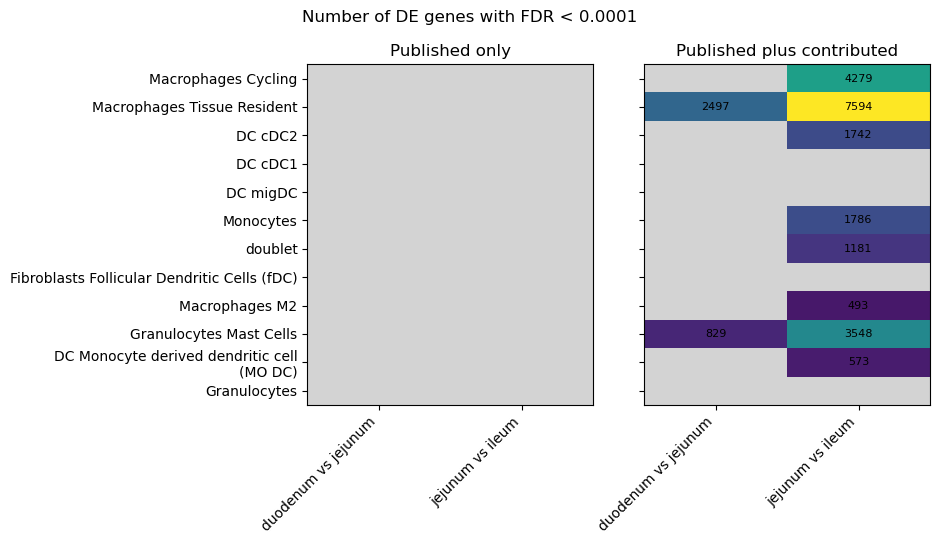

In [50]:
def de_count_for_celltype(ad_in, celltype, seg_a, seg_b, min_cells=50, fdr_cut=0.05):
    sub = ad_in[ad_in.obs[ct_col].astype(str) == str(celltype)].copy()
    sub = sub[sub.obs["segment_simple"].isin([seg_a, seg_b])].copy()

    na = int((sub.obs["segment_simple"].astype(str) == seg_a).sum())
    nb = int((sub.obs["segment_simple"].astype(str) == seg_b).sum())
    if na < min_cells or nb < min_cells:
        return np.nan, na, nb

    sanitize_log1p_uns(sub)

    sc.pp.normalize_total(sub, target_sum=1e4)
    sc.pp.log1p(sub)
    sanitize_log1p_uns(sub)

    sc.tl.rank_genes_groups(
        sub,
        groupby="segment_simple",
        groups=[seg_a],
        reference=seg_b,
        method="wilcoxon",
        use_raw=False,
    )

    df = sc.get.rank_genes_groups_df(sub, group=seg_a)
    if "pvals_adj" not in df.columns:
        return np.nan, na, nb

    n_sig = int((df["pvals_adj"].values < fdr_cut).sum())
    return n_sig, na, nb

def build_matrix(ad_in, min_cells=50, fdr_cut=0.001):
    mat = pd.DataFrame(index=celltypes, columns=[c[2] for c in comparisons], dtype=float)
    nobs = pd.DataFrame(index=celltypes, columns=[c[2] for c in comparisons], dtype=object)

    for ct in celltypes:
        for seg_a, seg_b, cname in comparisons:
            n_sig, na, nb = de_count_for_celltype(ad_in, ct, seg_a, seg_b, min_cells=min_cells, fdr_cut=fdr_cut)
            mat.loc[ct, cname] = n_sig
            nobs.loc[ct, cname] = str(na) + "/" + str(nb)

    return mat, nobs

mat_pub, nobs_pub = build_matrix(ad_pub, min_cells=50, fdr_cut=0.0001)
mat_all, nobs_all = build_matrix(ad_all, min_cells=50, fdr_cut=0.0001)

vmax = np.nanmax([np.nanmax(mat_pub.values), np.nanmax(mat_all.values)])
if not np.isfinite(vmax):
    vmax = 1.0

cmap = plt.cm.viridis.copy()
cmap.set_bad("lightgray")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 5.5), sharey=True)

for ax, mat, title in [
    (axes[0], mat_pub, "Published only"),
    (axes[1], mat_all, "Published plus contributed"),
]:
    arr = mat.values.astype(float)
    im = ax.imshow(arr, aspect="auto", cmap=cmap, vmin=0, vmax=vmax)

    ax.set_title(title)
    ax.set_xticks(range(mat.shape[1]))
    ax.set_xticklabels(mat.columns, rotation=45, ha="right")

    ax.set_yticks(range(mat.shape[0]))
    ax.set_yticklabels(mat.index)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = arr[i, j]
            if np.isfinite(val):
                ax.text(j, i, str(int(val)), ha="center", va="center", fontsize=8)

fig.suptitle("Number of DE genes with FDR < 0.0001", y=0.98)
plt.tight_layout()
plt.show()

In [53]:
# fig, axes = plt.subplots(1, 2, figsize=(9.5, 5.5), sharey=True)

# for ax, mat, title in [
#     (axes[0], mat_pub, "Published only"),
#     (axes[1], mat_all, "Published plus contributed"),
# ]:
#     arr = mat.values.astype(float)
#     im = ax.imshow(arr, aspect="auto", cmap=cmap, vmin=0, vmax=vmax)

#     ax.set_title(title)
#     ax.set_xticks(range(mat.shape[1]))
#     ax.set_xticklabels(mat.columns, rotation=45, ha="right")

#     ax.set_yticks(range(mat.shape[0]))
#     ax.set_yticklabels(mat.index)

#     for i in range(mat.shape[0]):
#         for j in range(mat.shape[1]):
#             val = arr[i, j]
#             if np.isfinite(val):
#                 ax.text(j, i, str(int(val)), ha="center", va="center", fontsize=8)

# cbar = fig.colorbar(im, ax=axes, shrink=0.9)
# cbar.set_label("Number of DE genes with q < 0.05")

# plt.tight_layout()
# plt.show()


In [52]:
# import scanpy as sc
# import numpy as np

# print(type(adata.uns))
# print(adata.uns)

In [51]:
# import numpy as np
# import matplotlib.pyplot as plt

# def stars(q):
#     if q < 1e-3:
#         return "***"
#     if q < 1e-2:
#         return "**"
#     if q < 5e-2:
#         return "*"
#     return ""

# genes_show = ["MYD88", "APOE"]

# sub = res[res["gene"].isin(genes_show)].copy()

# for gene in genes_show:
#     df = sub[sub["gene"] == gene].pivot(index="celltype", columns="dataset_set", values="log2_fc")
#     df = df.reindex(index=cts)
#     fig, ax = plt.subplots(figsize=(5.2, 0.35 * max(6, df.shape[0])))
#     im = ax.imshow(df.values, aspect="auto")
#     ax.set_yticks(range(df.shape[0]))
#     ax.set_yticklabels(df.index)
#     ax.set_xticks(range(df.shape[1]))
#     ax.set_xticklabels(df.columns, rotation=30, ha="right")
#     ax.set_title(gene + " log2FC (jejunum vs ileum)")

#     for i, ct in enumerate(df.index):
#         for j, ds in enumerate(df.columns):
#             qv = sub[(sub["gene"] == gene) & (sub["celltype"] == ct) & (sub["dataset_set"] == ds)]["q"]
#             if qv.shape[0] == 1:
#                 ax.text(j, i, stars(float(qv.iloc[0])), ha="center", va="center")

#     plt.tight_layout()
#     plt.show()


## Jejunum myeloid compositions

/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


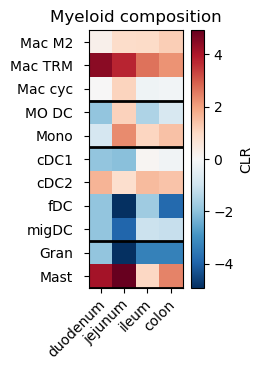

In [82]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

adata = sc.read_h5ad("/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/myeloid.h5ad")

tissue_col = "tissue_ontology_term"
ct_col = "Prelim annotation"

uberon_to_segment = {
    "UBERON:0002114": "duodenum",
    "UBERON:0002115": "jejunum",
    "UBERON:0002116": "ileum",
    "UBERON:0001155": "colon",
}

def segment_from_tissue(x):
    s = str(x)
    if s in uberon_to_segment:
        return uberon_to_segment[s]
    sl = s.lower()
    if "duod" in sl:
        return "duodenum"
    if "jejun" in sl:
        return "jejunum"
    if "ile" in sl:
        return "ileum"
    if "colon" in sl or "large intestine" in sl:
        return "colon"
    return "other"

seg_order = ["duodenum", "jejunum", "ileum", "colon"]

ad = adata.copy()
ad.obs["segment_simple"] = ad.obs[tissue_col].map(segment_from_tissue)
ad = ad[ad.obs["segment_simple"].isin(seg_order)].copy()

counts = pd.crosstab(ad.obs["segment_simple"], ad.obs[ct_col].astype(str)).reindex(seg_order).fillna(0)

pseudocount = 0.5
x = counts.astype(float) + pseudocount
x = x.div(x.sum(axis=1), axis=0)

logx = np.log(x.values)
clr = logx - logx.mean(axis=1, keepdims=True)
clr_df = pd.DataFrame(clr, index=counts.index, columns=counts.columns)

short = {
    "Macrophages Tissue Resident": "Mac TRM",
    "Macrophages M2": "Mac M2",
    "Macrophages Cycling": "Mac cyc",
    "Monocytes": "Mono",
    "DC cDC1": "cDC1",
    "DC cDC2": "cDC2",
    "DC migDC": "migDC",
    "DC Monocyte derived dendritic cell\n(MO DC)": "MO DC",
    "Granulocytes": "Gran",
    "Granulocytes Mast Cells": "Mast",
    "Fibroblasts Follicular Dendritic Cells (fDC)": "fDC",
    "doublet": "dblt",
}

def ct_group(ct):
    s = str(ct).lower()
    if "macrophage" in s:
        return "Macrophage"
    if "monocyte" in s:
        return "Monocyte"
    if "dc" in s or "dendritic" in s:
        return "DC"
    if "granulocyte" in s or "mast" in s:
        return "Granulocyte"
    return "Other"

meta = pd.DataFrame({"ct": clr_df.columns})
meta["group"] = meta["ct"].map(ct_group)
meta["short"] = meta["ct"].map(lambda x: short.get(x, str(x)))

group_order = ["Macrophage", "Monocyte", "DC", "Granulocyte", "Other"]
meta["group"] = pd.Categorical(meta["group"], categories=group_order, ordered=True)

meta = meta.sort_values(["group", "short"])
meta = meta[meta["ct"].astype(str) != "doublet"].copy()

ct_order = meta["ct"].tolist()
clr_df = clr_df[ct_order]

mat = clr_df.values.T
row_labels = meta["short"].tolist()

v = float(np.nanquantile(np.abs(mat), 0.95))
if not np.isfinite(v) or v == 0:
    v = 1.0

fig, ax = plt.subplots(figsize=(3.6, 3.8))
im = ax.imshow(mat, vmin=-v, vmax=v, cmap="RdBu_r", aspect="equal")

ax.set_xticks(range(len(seg_order)))
ax.set_xticklabels(seg_order, rotation=45, ha="right")
import matplotlib.transforms as mtransforms

dx_pts = 5
offset = mtransforms.ScaledTranslation(dx_pts / 72.0, 0, fig.dpi_scale_trans)

for lab in ax.get_xticklabels():
    lab.set_transform(lab.get_transform() + offset)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=10)

ax.yaxis.set_ticks_position("left")
ax.tick_params(axis="y", pad=8)

ax.set_title("Myeloid composition")

group_sizes = meta["group"].value_counts().reindex(group_order).fillna(0).astype(int).tolist()
pos = 0
for gs in group_sizes:
    if gs > 0:
        pos += gs
        ax.axhline(pos - 0.5, color="black", linewidth=2)


cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cbar.set_label("CLR")

plt.tight_layout()
plt.show()
